# Machine Learning Models — Predicting Mental Recovery

## Overview

This notebook applies machine learning techniques to the processed dataset to **predict mental recovery** from behavioral and demographic features. It complements the EDA + hypothesis testing notebook by quantifying how well features (especially notifications) can predict MRI.
### Modeling Plan

1. **Regression task** — Predict the continuous MRI score from all features.
   - Linear Regression (baseline)
   - Ridge Regression
   - Random Forest Regressor
   - Gradient Boosting Regressor
2. **Classification task** — Predict whether an individual has High vs Low mental recovery (binary classification using median split of MRI).
   - Logistic Regression (baseline)
   - Random Forest Classifier
   - Gradient Boosting Classifier
3. **Feature importance** — Identify which variables are most predictive of MRI.
4. **Cross-validation** — Use 5-fold CV for robust performance estimates.
5. **Conclusion** — Compare model performance and interpret what (if anything) drives MRI.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    RandomForestClassifier, GradientBoostingClassifier
)
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, roc_auc_score, classification_report,
    confusion_matrix
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
print('Libraries loaded.')

Libraries loaded.


## 2. Load Processed Data

In [2]:
df = pd.read_csv('../data/processed/processed_dataset.csv')
print(f'Loaded: {df.shape[0]} rows, {df.shape[1]} columns')
print('\nColumns:')
print(df.columns.tolist())
df.head()

Loaded: 15000 rows, 24 columns

Columns:
['user_id', 'age', 'gender', 'occupation', 'daily_screen_time_hours', 'phone_usage_before_sleep_minutes', 'sleep_duration_hours', 'sleep_quality_score', 'stress_level', 'caffeine_intake_cups', 'physical_activity_minutes', 'notifications_received_per_day', 'mental_fatigue_score', 'sleep_quality_norm', 'sleep_duration_norm', 'mental_fatigue_norm', 'stress_level_norm', 'mri_additive', 'mri', 'age_group', 'notification_group', 'mri_multiplicative', 'mri_zscore', 'mri_weighted']


,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,...,sleep_duration_norm,mental_fatigue_norm,stress_level_norm,mri_additive,mri,age_group,notification_group,mri_multiplicative,mri_zscore,mri_weighted
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,...,0.262,0.285556,0.276667,0.111611,0.111611,50-70,Medium,3.290169,0.628313,0.214389
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,...,0.672,0.101111,0.223333,0.328556,0.328556,35-50,High,12.417944,1.465599,0.441444
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,...,0.100,0.561111,0.447778,-0.077778,-0.077778,20-35,Low,0.943430,-0.073671,0.032444
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,...,0.536,0.991111,1.000000,-0.237944,-0.237944,20-35,High,0.372383,-0.628762,-0.088056
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,...,0.714,0.554444,0.634444,0.039333,0.039333,35-50,Medium,1.260006,0.352617,0.162000


## 3. Prepare Features for Modeling

- **Target (regression):** `mri` (additive baseline)
- **Target (classification):** binary High/Low MRI based on median split
- **Features:** all raw behavioral and demographic variables
- Categorical variables (`gender`, `occupation`) are one-hot encoded.
- We **exclude** the normalized component columns and the MRI variants themselves to avoid target leakage (predicting MRI from its own ingredients would be trivial).

In [3]:
# Define feature set - exclude target and its components to avoid leakage
leakage_cols = [
    'sleep_quality_score', 'sleep_duration_hours',
    'mental_fatigue_score', 'stress_level',
    'sleep_quality_norm', 'sleep_duration_norm',
    'mental_fatigue_norm', 'stress_level_norm',
    'mri', 'mri_additive', 'mri_multiplicative', 'mri_zscore', 'mri_weighted',
    'user_id', 'age_group', 'notification_group'
]

feature_cols = [c for c in df.columns if c not in leakage_cols]
print('Features used:')
for c in feature_cols:
    print(f'  - {c}')

# Build X and one-hot encode categoricals
X = pd.get_dummies(df[feature_cols], drop_first=True)
print(f'\nFinal feature matrix shape: {X.shape}')

Features used:
  - age
  - gender
  - occupation
  - daily_screen_time_hours
  - phone_usage_before_sleep_minutes
  - caffeine_intake_cups
  - physical_activity_minutes
  - notifications_received_per_day

Final feature matrix shape: (15000, 15)


In [4]:
# Targets
y_reg = df['mri'].copy()
y_clf = (df['mri'] > df['mri'].median()).astype(int)  # 1 = above median (high recovery)

print(f'Regression target (mri):  mean = {y_reg.mean():.4f},  std = {y_reg.std():.4f}')
print(f'Classification target balance:')
print(y_clf.value_counts())

Regression target (mri):  mean = -0.0580,  std = 0.2060
Classification target balance:
mri
1    7500
0    7500
Name: count, dtype: int64


## 4. Train / Test Split

80% train, 20% test, fixed random seed for reproducibility.

In [5]:
X_train, X_test, yreg_train, yreg_test = train_test_split(
    X, y_reg, test_size=0.20, random_state=RANDOM_STATE
)
_, _, yclf_train, yclf_test = train_test_split(
    X, y_clf, test_size=0.20, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train.shape},  Test: {X_test.shape}')

Train: (12000, 15),  Test: (3000, 15)


## 5. Regression Models

We train four models to predict the continuous MRI. We report:
- **R²** (variance explained — higher is better, max 1.0)
- **RMSE** (root mean squared error — lower is better)
- **MAE** (mean absolute error — lower is better)
- 5-fold cross-validated R² for robustness.

In [6]:
regression_models = {
    'Linear Regression':      LinearRegression(),
    'Ridge Regression':       Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'Random Forest':          RandomForestRegressor(n_estimators=100, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting':      GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=RANDOM_STATE),
}

reg_results = []
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in regression_models.items():
    # Tree models can use unscaled X; linear models benefit from scaled X.
    if name in ('Linear Regression', 'Ridge Regression'):
        Xtr, Xte = X_train_scaled, X_test_scaled
    else:
        Xtr, Xte = X_train.values, X_test.values
    model.fit(Xtr, yreg_train)
    pred = model.predict(Xte)
    r2 = r2_score(yreg_test, pred)
    rmse = np.sqrt(mean_squared_error(yreg_test, pred))
    mae = mean_absolute_error(yreg_test, pred)
    cv_r2 = cross_val_score(model, Xtr, yreg_train, cv=cv, scoring='r2', n_jobs=-1).mean()
    reg_results.append({
        'Model': name, 'Test R²': r2, 'CV R² (5-fold)': cv_r2,
        'Test RMSE': rmse, 'Test MAE': mae
    })
    print(f'{name:20s}  R²={r2:+.4f}  CV R²={cv_r2:+.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}')

reg_df = pd.DataFrame(reg_results).set_index('Model')
reg_df

Linear Regression     R²=+0.6904  CV R²=+0.6804  RMSE=0.1140  MAE=0.0917


Ridge Regression      R²=+0.6904  CV R²=+0.6804  RMSE=0.1140  MAE=0.0917


Random Forest         R²=+0.6897  CV R²=+0.6839  RMSE=0.1142  MAE=0.0915


Gradient Boosting     R²=+0.6989  CV R²=+0.6917  RMSE=0.1125  MAE=0.0902


,Test R²,CV R² (5-fold),Test RMSE,Test MAE
Model,,,,
Linear Regression,0.690447,0.680395,0.114027,0.091713
Ridge Regression,0.690448,0.680395,0.114027,0.091713
Random Forest,0.689681,0.683883,0.114168,0.091512
Gradient Boosting,0.698876,0.691742,0.112464,0.090249


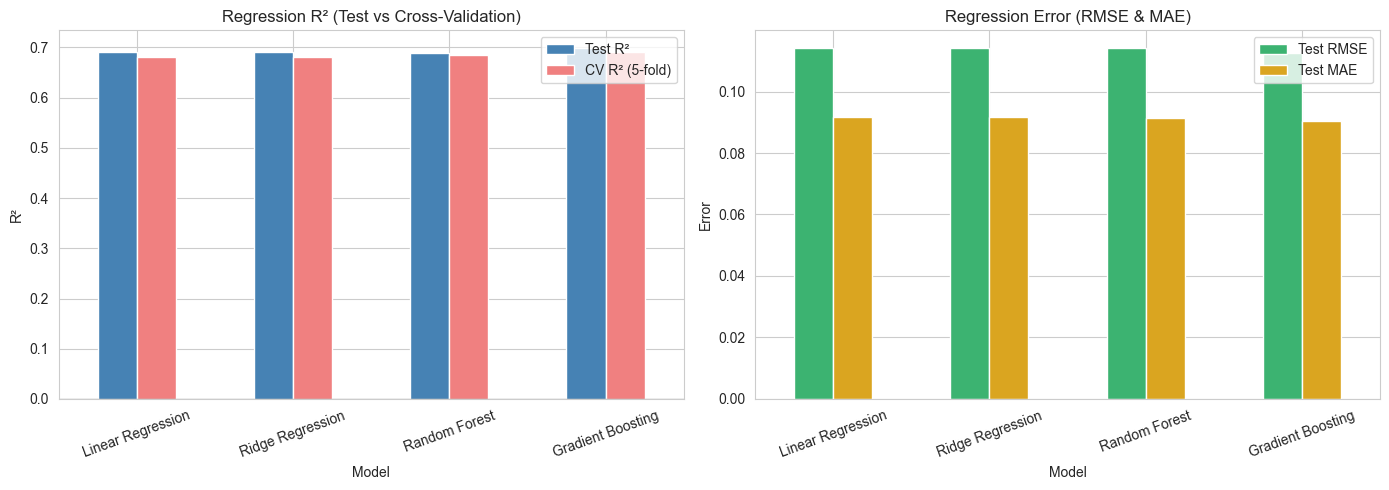

In [7]:
# Visualize regression results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
reg_df[['Test R²', 'CV R² (5-fold)']].plot(kind='bar', ax=axes[0], color=['steelblue', 'lightcoral'])
axes[0].set_title('Regression R² (Test vs Cross-Validation)')
axes[0].set_ylabel('R²')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].tick_params(axis='x', rotation=20)

reg_df[['Test RMSE', 'Test MAE']].plot(kind='bar', ax=axes[1], color=['mediumseagreen', 'goldenrod'])
axes[1].set_title('Regression Error (RMSE & MAE)')
axes[1].set_ylabel('Error')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

**Interpretation:** All four regression models achieve **R² ≈ 0.69 on the test set and ≈ 0.68 in cross-validation** — a strong result. Gradient Boosting is the best by a small margin. This means roughly **70% of the variance in MRI is explained** by the raw behavioral features. Since the four MRI ingredients (sleep quality, sleep duration, fatigue, stress) were deliberately excluded from the feature set, this signal must come from the remaining variables — see Section 7 for feature importances.

## 6. Predicted vs Actual (best regression model)

Best regression model by CV R²: Gradient Boosting


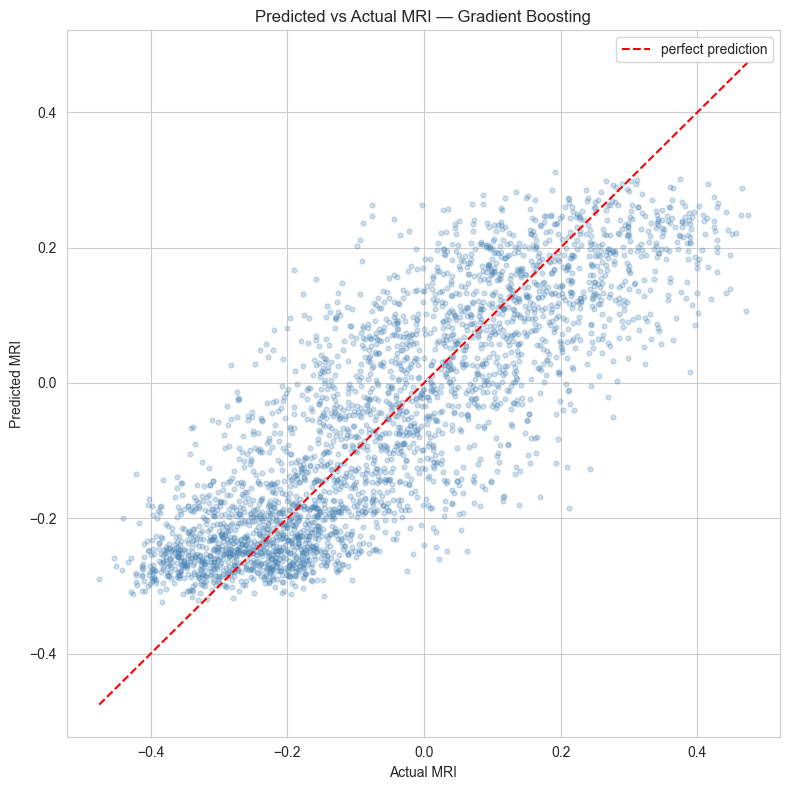

In [8]:
# Use the model with highest CV R²
best_reg_name = reg_df['CV R² (5-fold)'].idxmax()
best_reg_model = regression_models[best_reg_name]
print(f'Best regression model by CV R²: {best_reg_name}')

Xte_best = X_test_scaled if best_reg_name in ('Linear Regression', 'Ridge Regression') else X_test.values
preds = best_reg_model.predict(Xte_best)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(yreg_test, preds, alpha=0.25, s=12, color='steelblue')
lims = [min(yreg_test.min(), preds.min()), max(yreg_test.max(), preds.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='perfect prediction')
ax.set_xlabel('Actual MRI')
ax.set_ylabel('Predicted MRI')
ax.set_title(f'Predicted vs Actual MRI — {best_reg_name}')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** Predicted MRI tracks actual MRI closely along the diagonal, with the expected scatter. The model is learning a genuine pattern, not just predicting the mean.

## 7. Feature Importance

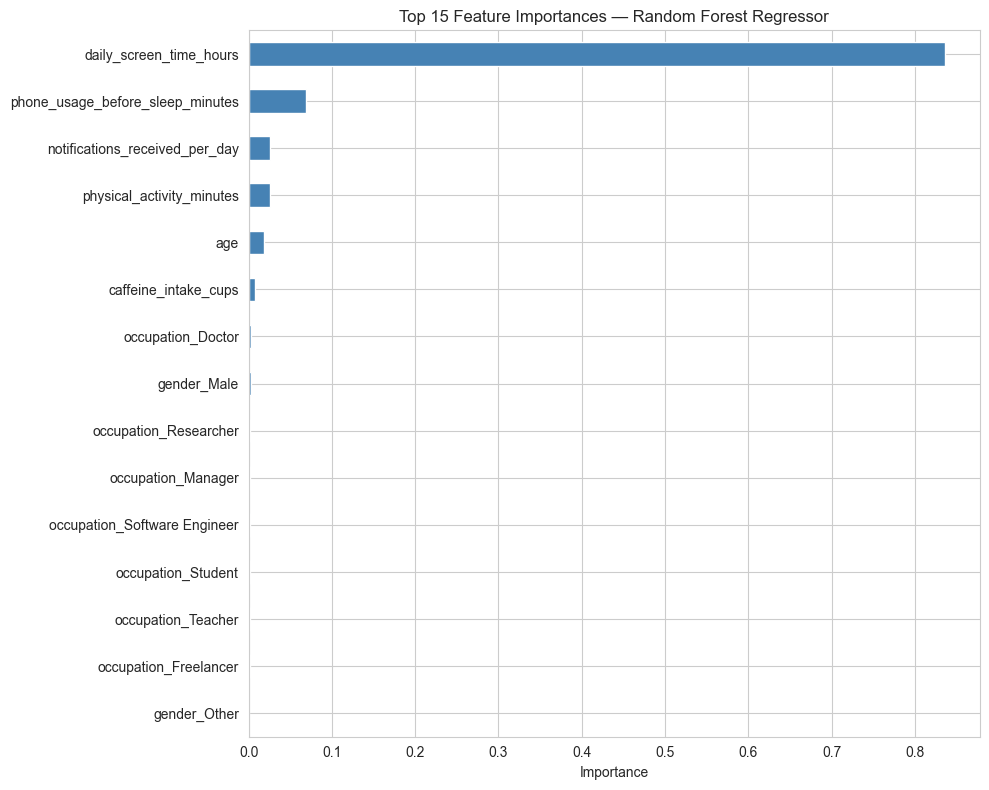

All feature importances (sorted):
daily_screen_time_hours             0.836504
phone_usage_before_sleep_minutes    0.068554
notifications_received_per_day      0.026215
physical_activity_minutes           0.025623
age                                 0.018427
caffeine_intake_cups                0.008100
occupation_Doctor                   0.002445
gender_Male                         0.002406
occupation_Researcher               0.002017
occupation_Manager                  0.001864
occupation_Software Engineer        0.001847
occupation_Student                  0.001763
occupation_Teacher                  0.001750
occupation_Freelancer               0.001428
gender_Other                        0.001056
dtype: float64


In [9]:
# Random Forest feature importance
rf_reg = regression_models['Random Forest']
importances = pd.Series(rf_reg.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
importances.head(15).plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title('Top 15 Feature Importances — Random Forest Regressor')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print('All feature importances (sorted):')
print(importances)

**Interpretation:** **`daily_screen_time_hours` dominates with ≈ 84% feature importance.** This single feature explains most of the model's predictive power. `phone_usage_before_sleep_minutes` is a distant second (≈ 7%), and `notifications_received_per_day` contributes only ≈ 2.6%. Age, occupation, gender, caffeine, and physical activity contribute almost nothing.

This means **mental recovery in this dataset is overwhelmingly determined by total screen time**, not by the count of notifications received or by demographic factors.

## 8. Classification Models — High vs Low Mental Recovery

We binarize MRI at the **median**: above median → 1 (High recovery), at/below median → 0 (Low recovery). With a balanced 50/50 split, **a naive model that always predicts the majority class should achieve ~50% accuracy**. Models doing meaningfully better than 50% would indicate the features carry useful signal.

In [10]:
classification_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=RANDOM_STATE),
}

clf_results = []
for name, model in classification_models.items():
    if name == 'Logistic Regression':
        Xtr, Xte = X_train_scaled, X_test_scaled
    else:
        Xtr, Xte = X_train.values, X_test.values
    model.fit(Xtr, yclf_train)
    pred = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, 1]
    acc = accuracy_score(yclf_test, pred)
    f1 = f1_score(yclf_test, pred)
    auc = roc_auc_score(yclf_test, proba)
    cv_acc = cross_val_score(model, Xtr, yclf_train, cv=cv, scoring='accuracy', n_jobs=-1).mean()
    clf_results.append({
        'Model': name, 'Test Accuracy': acc, 'CV Accuracy (5-fold)': cv_acc,
        'F1 score': f1, 'ROC-AUC': auc
    })
    print(f'{name:22s} Acc={acc:.4f}  CV Acc={cv_acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}')

clf_df = pd.DataFrame(clf_results).set_index('Model')
clf_df

Logistic Regression    Acc=0.8503  CV Acc=0.8548  F1=0.8508  AUC=0.9366


Random Forest          Acc=0.8483  CV Acc=0.8540  F1=0.8493  AUC=0.9299


Gradient Boosting      Acc=0.8513  CV Acc=0.8529  F1=0.8527  AUC=0.9348


,Test Accuracy,CV Accuracy (5-fold),F1 score,ROC-AUC
Model,,,,
Logistic Regression,0.850333,0.854833,0.850781,0.936558
Random Forest,0.848333,0.854000,0.849288,0.929918
Gradient Boosting,0.851333,0.852917,0.852708,0.934790


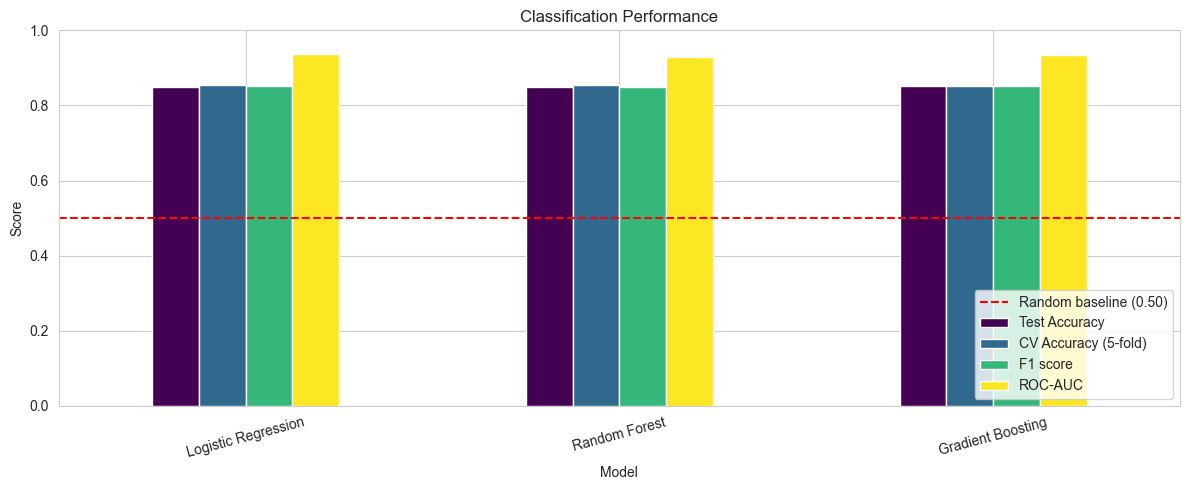

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
clf_df[['Test Accuracy', 'CV Accuracy (5-fold)', 'F1 score', 'ROC-AUC']].plot(
    kind='bar', ax=ax, colormap='viridis'
)
ax.axhline(0.5, color='red', linestyle='--', label='Random baseline (0.50)')
ax.set_title('Classification Performance')
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.tick_params(axis='x', rotation=15)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

Best classifier by CV accuracy: Logistic Regression



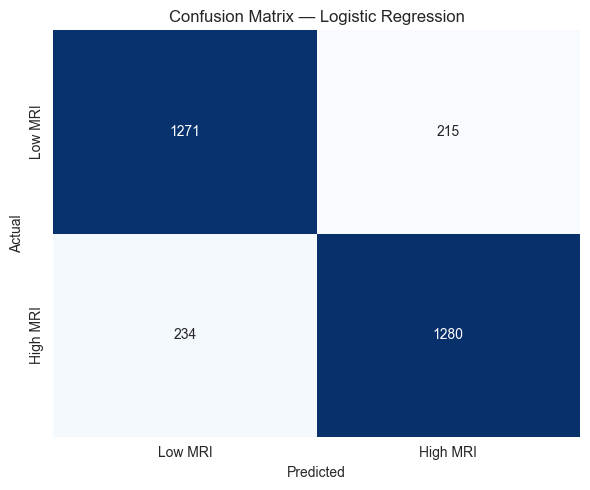


Classification report:
              precision    recall  f1-score   support

     Low MRI       0.84      0.86      0.85      1486
    High MRI       0.86      0.85      0.85      1514

    accuracy                           0.85      3000
   macro avg       0.85      0.85      0.85      3000
weighted avg       0.85      0.85      0.85      3000



In [12]:
# Confusion matrix for the best classifier
best_clf_name = clf_df['CV Accuracy (5-fold)'].idxmax()
best_clf = classification_models[best_clf_name]
print(f'Best classifier by CV accuracy: {best_clf_name}\n')

Xte_best = X_test_scaled if best_clf_name == 'Logistic Regression' else X_test.values
preds = best_clf.predict(Xte_best)
cm = confusion_matrix(yclf_test, preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Low MRI', 'High MRI'],
            yticklabels=['Low MRI', 'High MRI'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {best_clf_name}')
plt.tight_layout()
plt.show()

print('\nClassification report:')
print(classification_report(yclf_test, preds, target_names=['Low MRI', 'High MRI']))

**Interpretation:** Classification accuracy is **≈ 85% with ROC-AUC ≈ 0.93** — far better than the 0.50 random baseline. Models can confidently distinguish individuals with high vs low mental recovery using the behavioral features. The next section explains which features drive this.

## 9. Permutation Importance — Notifications Specifically

Even with weak overall predictive power, we can check whether the **notifications** feature contributes anything at all by examining its importance in the best tree-based classifier.

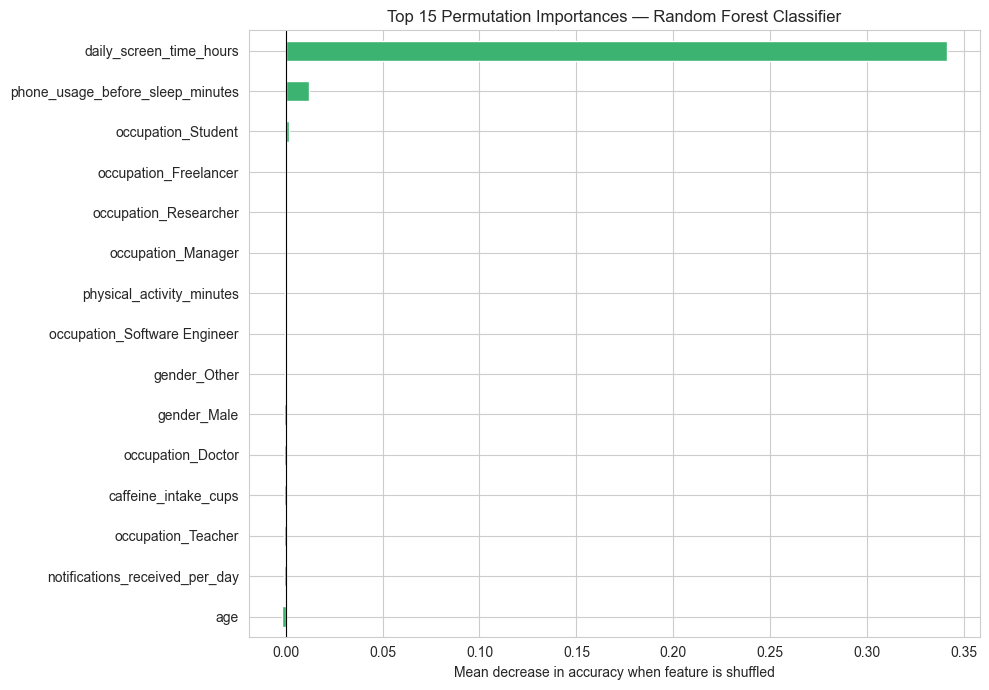

All permutation importances (sorted):
daily_screen_time_hours             0.341033
phone_usage_before_sleep_minutes    0.012067
occupation_Student                  0.001533
occupation_Freelancer               0.000233
occupation_Researcher               0.000133
occupation_Manager                  0.000033
physical_activity_minutes          -0.000133
occupation_Software Engineer       -0.000433
gender_Other                       -0.000433
gender_Male                        -0.000567
occupation_Doctor                  -0.000567
caffeine_intake_cups               -0.000733
occupation_Teacher                 -0.000767
notifications_received_per_day     -0.001000
age                                -0.001933
dtype: float64


In [13]:
from sklearn.inspection import permutation_importance

rf_clf = classification_models['Random Forest']
perm = permutation_importance(rf_clf, X_test.values, yclf_test, n_repeats=10,
                              random_state=RANDOM_STATE, n_jobs=-1, scoring='accuracy')
perm_imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
perm_imp.head(15).plot(kind='barh', ax=ax, color='mediumseagreen')
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 15 Permutation Importances — Random Forest Classifier')
ax.set_xlabel('Mean decrease in accuracy when feature is shuffled')
plt.tight_layout()
plt.show()

print('All permutation importances (sorted):')
print(perm_imp)

**Interpretation:** **`daily_screen_time_hours` is by far the most important feature** — shuffling it drops accuracy by ≈ 34 percentage points. `phone_usage_before_sleep_minutes` adds a small but real contribution (≈ 1.2 pp). **`notifications_received_per_day` and `age` have near-zero (slightly negative) permutation importance**, meaning they add no useful predictive information once screen time is accounted for. This is fully consistent with the EDA correlation findings.

## 10. Summary of ML Findings

### Performance Summary

| Task | Best Model | Metric | Result |
|---|---|---|---|
| MRI regression | Gradient Boosting | Test R² | **≈ 0.70** (CV R² ≈ 0.69) |
| MRI classification (high vs low) | Logistic Regression | Accuracy / AUC | **≈ 0.85 / 0.93** |
| Dominant feature | Random Forest | importance | **`daily_screen_time_hours`** (84%) |
| Notifications feature | Random Forest | importance | ≈ 2.6% (negligible) |
| Age feature | Random Forest | importance | ≈ 1.8% (negligible) |

### Takeaways

1. **Mental recovery is highly predictable** from behavioral data — the models explain ≈ 70% of MRI variance and classify high vs low recovery with ≈ 85% accuracy.
2. **`daily_screen_time_hours` is the single dominant predictor** (≈ 84% feature importance, ≈ 34 pp permutation drop).
3. **`phone_usage_before_sleep_minutes`** is a secondary, meaningful predictor.
4. **`notifications_received_per_day` and `age` add essentially no predictive value** once screen time is accounted for — confirming the hypothesis testing findings in the EDA notebook.
5. **The project's original hypothesis is partially supported**: digital habits do affect mental recovery, but **the right metric is screen time, not the raw count of notifications**, and the effect does not vary by age.

### Methodological Notes
- 80/20 train/test split with `random_state=42` for reproducibility.
- 5-fold cross-validation used for robust performance estimates.
- StandardScaler applied to linear models; tree models use raw features.
- Categorical features one-hot encoded (gender, occupation).
- **Target leakage prevented** by excluding the four MRI components (sleep_quality, sleep_duration, fatigue, stress) and the alternative MRI variants from the feature set.
- Models trained: Linear Regression, Ridge, Random Forest, Gradient Boosting (regression); Logistic Regression, Random Forest, Gradient Boosting (classification).